# Additional Survey Plots

Supplementary visualisations for the Survation January 2026 AI Workforce Survey.  
Loads pre-computed CSVs from `outputs/survey_only/` (produced by `04_survey_analysis.ipynb`).

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ── paths ──
BASE = Path(".")
DATA_DIR = BASE / "outputs" / "survey_only"
OUT_DIR = BASE / "outputs" / "survey_only"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── style (matches 04_survey_analysis) ──
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
})

SECTOR_ORDER = [
    'Information Technology (IT)',
    'Financial Services',
    'Education',
    'Healthcare Services',
]
SECTOR_SHORT = {
    'Information Technology (IT)': 'IT',
    'Financial Services': 'Finance',
    'Education': 'Education',
    'Healthcare Services': 'Healthcare',
}
SECTOR_COLORS = {
    'Information Technology (IT)': '#3498DB',
    'Financial Services': '#2ECC71',
    'Education': '#9B59B6',
    'Healthcare Services': '#E74C3C',
}

def _clean_cols(df):
    """Normalise curly quotes and strip whitespace in column names."""
    df.columns = [c.replace('\u2019', "'").strip() for c in df.columns]
    return df

print("Setup complete.")

Setup complete.


---
## 1. Q1 — Organisational Enablement by Sector (Stacked Bar)

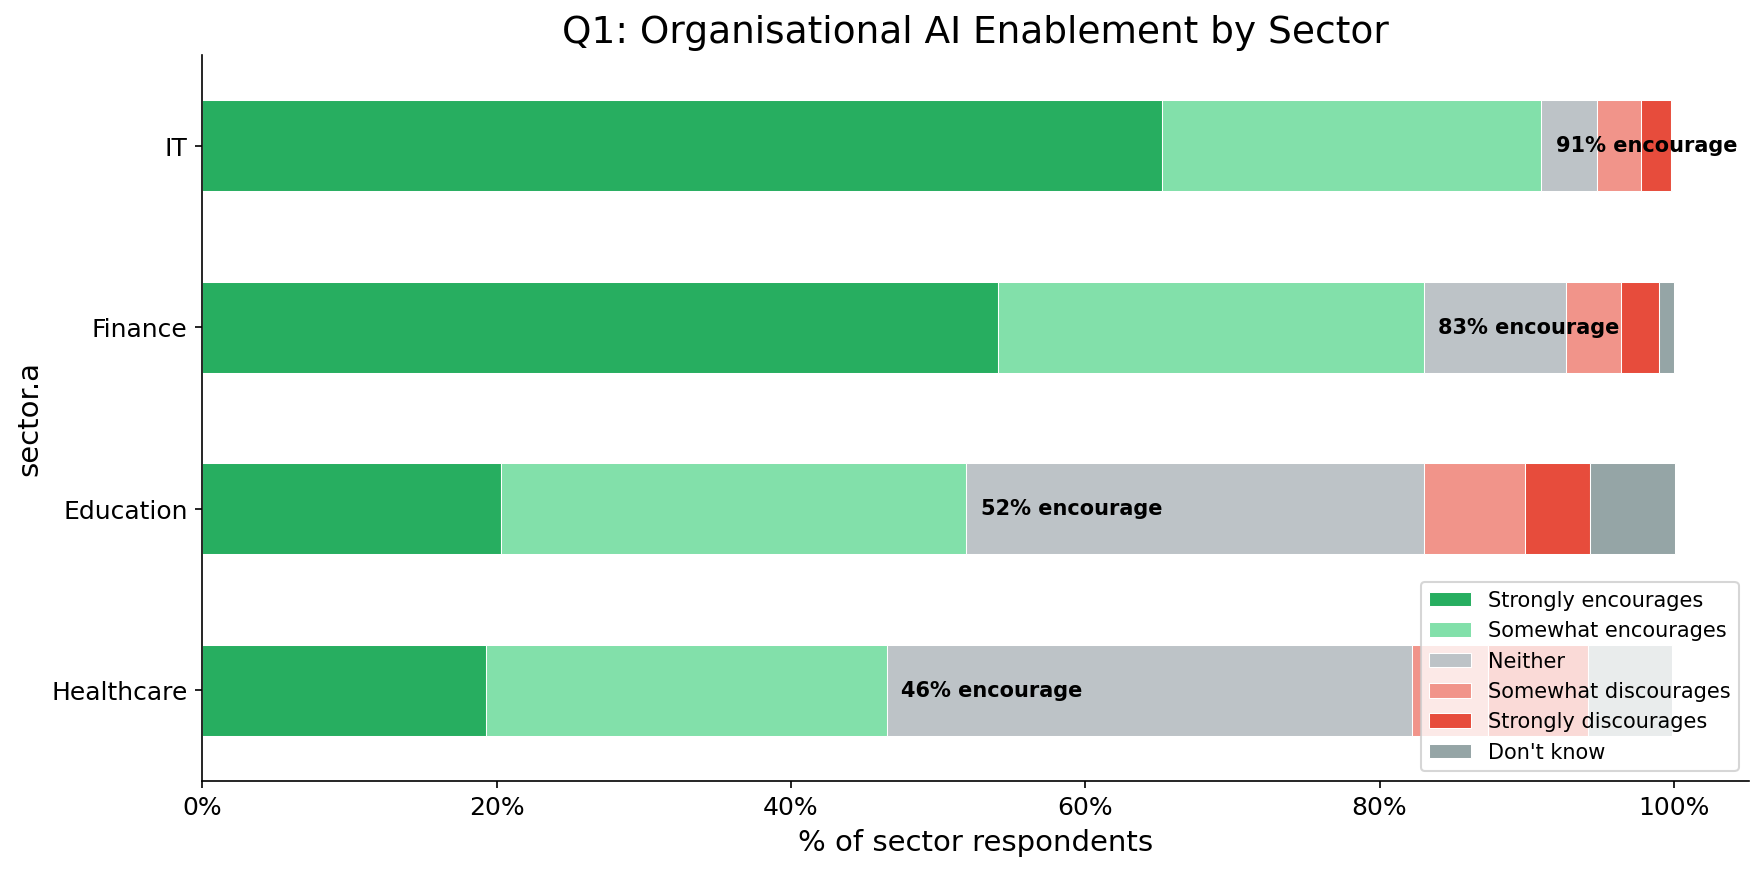

In [2]:
q1 = _clean_cols(pd.read_csv(DATA_DIR / "q1_org_encouragement_by_sector.csv"))
q1 = q1.set_index("sector.a").reindex(SECTOR_ORDER)

# Reorder columns from strongly encourages → strongly discourages
q1_cols = [
    'Strongly encourages AI adoption',
    'Somewhat encourages AI adoption',
    'Neither encourages nor discourages AI adoption',
    'Somewhat discourages AI adoption',
    'Strongly discourages AI adoption',
    "Don't know",
]
q1 = q1[q1_cols]

# Shorten labels
short_labels = [
    'Strongly encourages', 'Somewhat encourages', 'Neither',
    'Somewhat discourages', 'Strongly discourages', "Don't know",
]
q1.columns = short_labels

colors_q1 = ['#27AE60', '#82E0AA', '#BDC3C7', '#F1948A', '#E74C3C', '#95A5A6']

fig, ax = plt.subplots(figsize=(12, 6))
q1.rename(index=SECTOR_SHORT).plot.barh(
    stacked=True, ax=ax, color=colors_q1, edgecolor='white', linewidth=0.5,
)
ax.set_xlabel('% of sector respondents')
ax.set_title('Q1: Organisational AI Enablement by Sector')
ax.legend(loc='lower right', frameon=True, fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.invert_yaxis()

# Annotate combined encouragement %
for i, sector in enumerate(SECTOR_ORDER):
    pct = q1.loc[sector, 'Strongly encourages'] + q1.loc[sector, 'Somewhat encourages']
    ax.text(pct + 1, i, f'{pct:.0f}% encourage', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q1_enablement_by_sector_stacked.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Q4 — Sentiment by Sector (Stacked Bar)

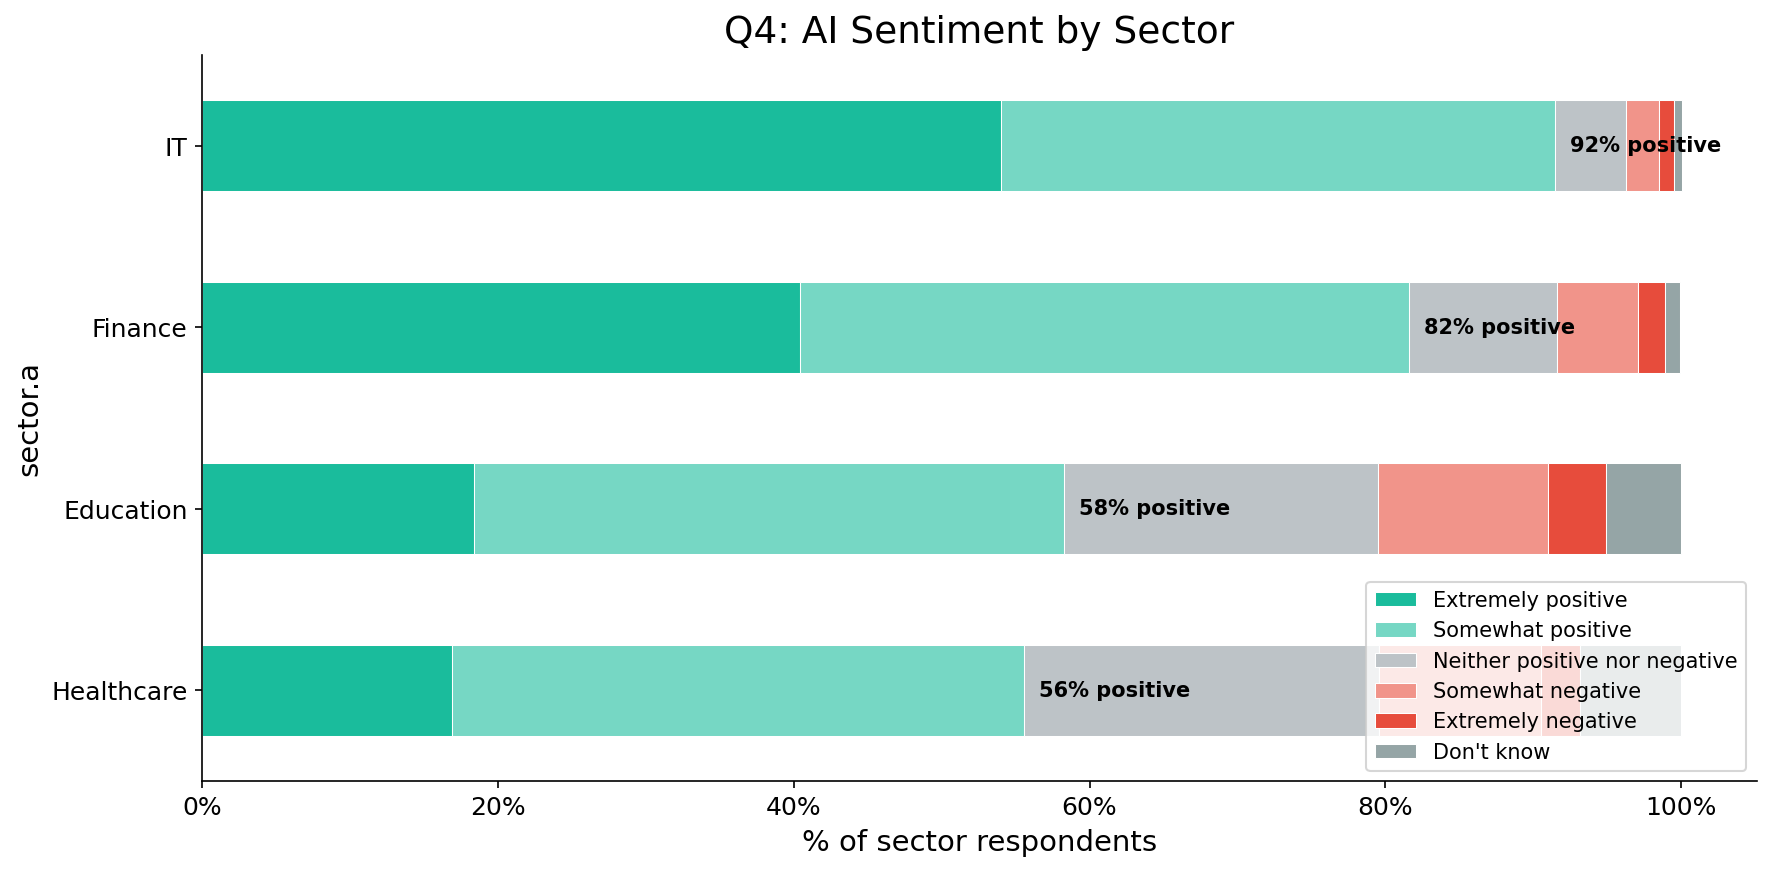

In [3]:
q4 = _clean_cols(pd.read_csv(DATA_DIR / "q4_sentiment_by_sector.csv"))
q4 = q4.set_index("sector.a").reindex(SECTOR_ORDER)

q4_cols = [
    'Extremely positive', 'Somewhat positive',
    'Neither positive nor negative',
    'Somewhat negative', 'Extremely negative',
    "Don't know",
]
q4 = q4[q4_cols]

colors_q4 = ['#1ABC9C', '#76D7C4', '#BDC3C7', '#F1948A', '#E74C3C', '#95A5A6']

fig, ax = plt.subplots(figsize=(12, 6))
q4.rename(index=SECTOR_SHORT).plot.barh(
    stacked=True, ax=ax, color=colors_q4, edgecolor='white', linewidth=0.5,
)
ax.set_xlabel('% of sector respondents')
ax.set_title('Q4: AI Sentiment by Sector')
ax.legend(loc='lower right', frameon=True, fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.invert_yaxis()

# Annotate positive %
for i, sector in enumerate(SECTOR_ORDER):
    pos = q4.loc[sector, 'Extremely positive'] + q4.loc[sector, 'Somewhat positive']
    ax.text(pos + 1, i, f'{pos:.0f}% positive', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q4_sentiment_by_sector_stacked.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Q6 — Task Usage Overall (Horizontal Bar)

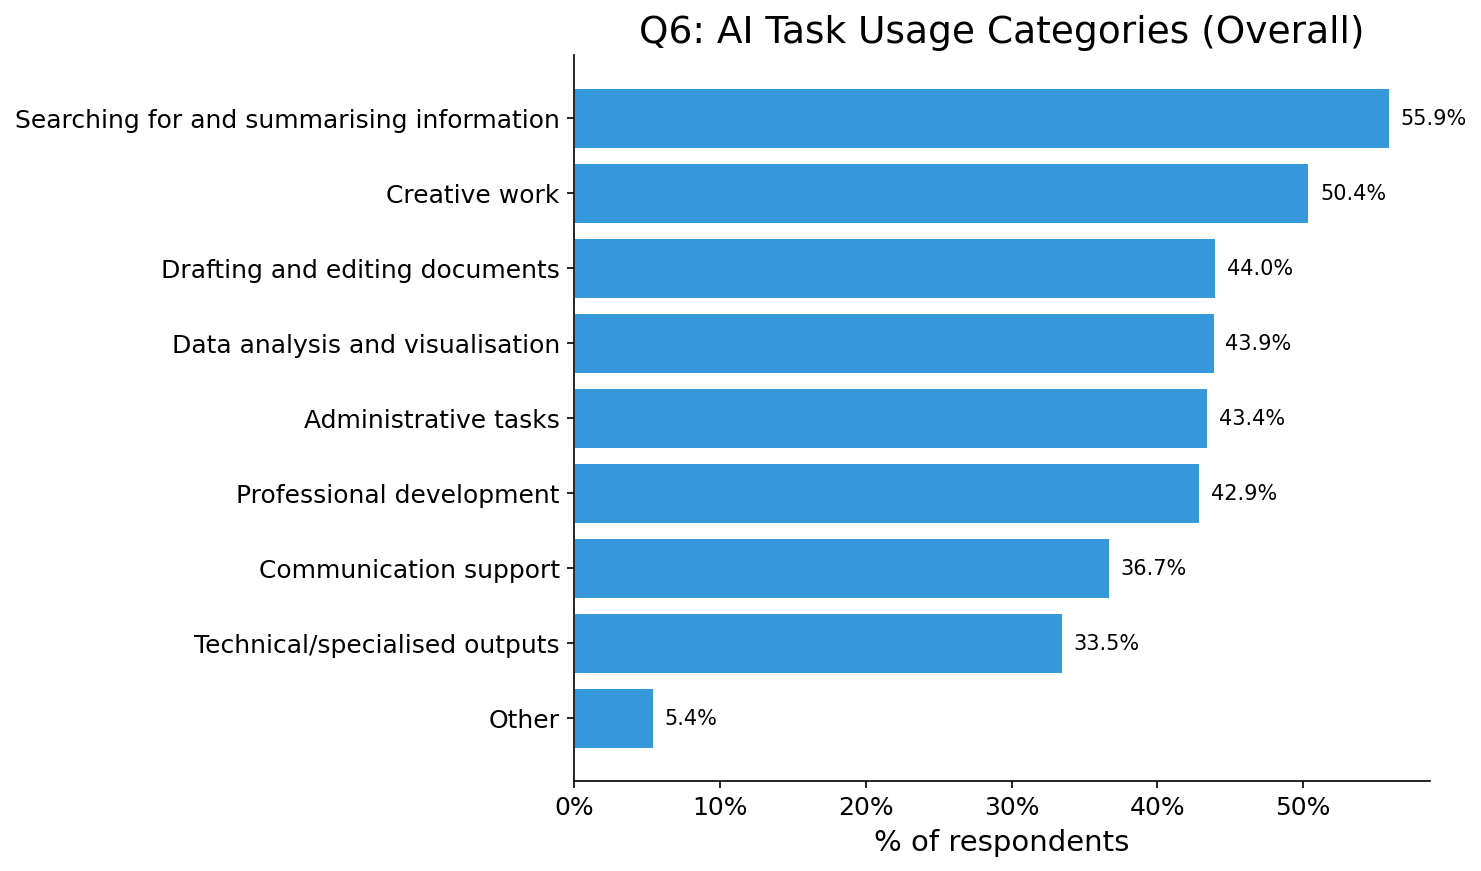

In [4]:
q6 = pd.read_csv(DATA_DIR / "q6_task_use_by_sector.csv")

# Compute overall % (weighted by sector N)
task_cols = [
    'Drafting and editing documents',
    'Data analysis and visualisation',
    'Searching for and summarising information',
    'Administrative tasks',
    'Communication support',
    'Creative work',
    'Technical/specialised outputs',
    'Professional development',
    'Other',
]
weights = q6['N'].values
overall = (q6[task_cols].multiply(weights, axis=0).sum() / weights.sum()).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(overall.index, overall.values, color='#3498DB', edgecolor='white', linewidth=0.5)
ax.set_xlabel('% of respondents')
ax.set_title('Q6: AI Task Usage Categories (Overall)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))

for bar, val in zip(bars, overall.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%',
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q6_task_usage_overall.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Q6 — Task Usage Heatmap (Sector × Category)

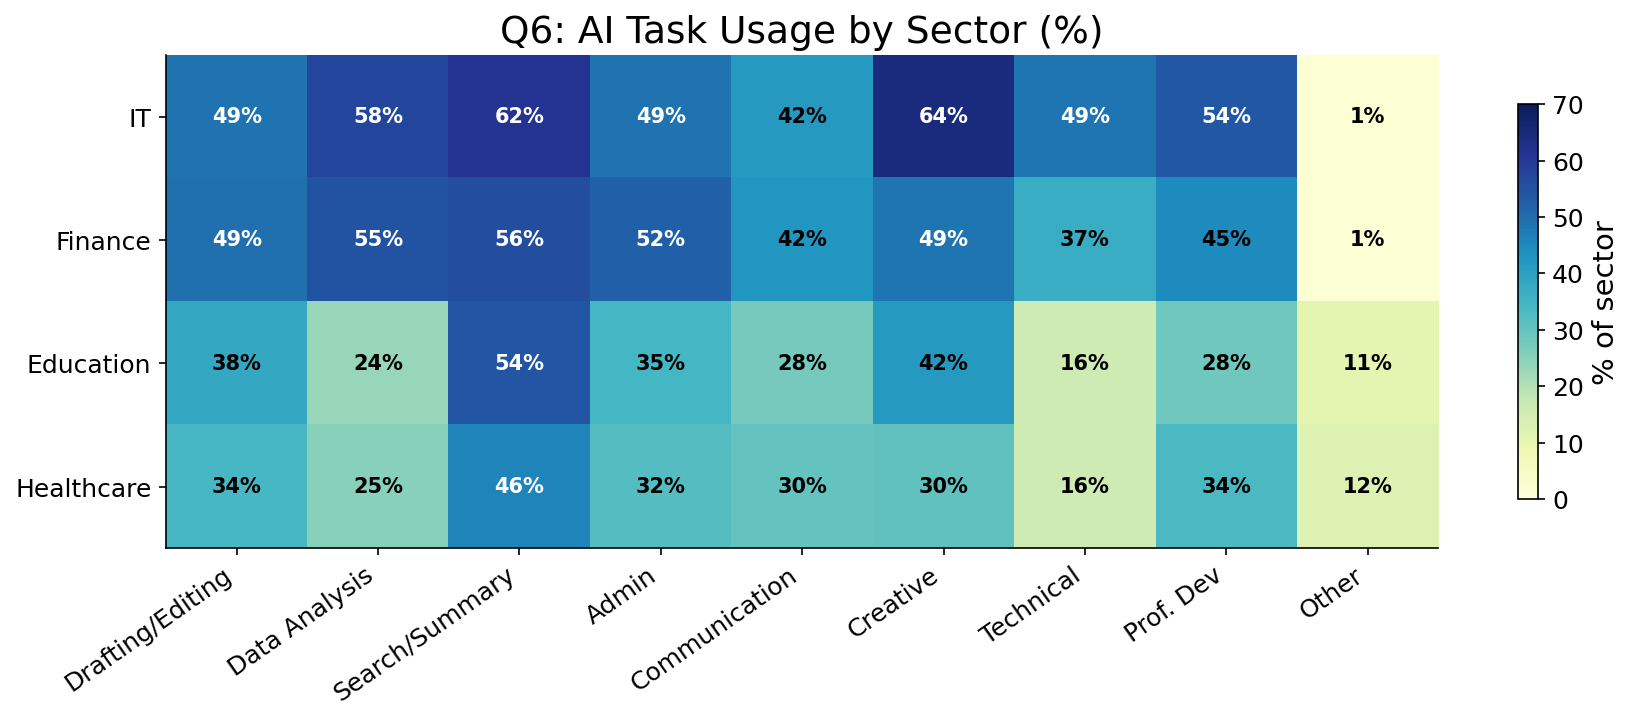

In [5]:
q6_heat = q6.set_index('Sector').reindex(SECTOR_ORDER)[task_cols]
q6_heat = q6_heat.rename(index=SECTOR_SHORT)

# Shorten column labels for readability
col_short = {
    'Drafting and editing documents': 'Drafting/Editing',
    'Data analysis and visualisation': 'Data Analysis',
    'Searching for and summarising information': 'Search/Summary',
    'Administrative tasks': 'Admin',
    'Communication support': 'Communication',
    'Creative work': 'Creative',
    'Technical/specialised outputs': 'Technical',
    'Professional development': 'Prof. Dev',
    'Other': 'Other',
}
q6_heat = q6_heat.rename(columns=col_short)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(q6_heat.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=70)

ax.set_xticks(range(len(q6_heat.columns)))
ax.set_xticklabels(q6_heat.columns, rotation=35, ha='right')
ax.set_yticks(range(len(q6_heat.index)))
ax.set_yticklabels(q6_heat.index)
ax.set_title('Q6: AI Task Usage by Sector (%)')

# Annotate cells
for i in range(q6_heat.shape[0]):
    for j in range(q6_heat.shape[1]):
        val = q6_heat.iloc[i, j]
        color = 'white' if val > 45 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=10,
                fontweight='bold', color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, label='% of sector')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q6_task_usage_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Q1 × Q9 — Enablement–Productivity Gradient

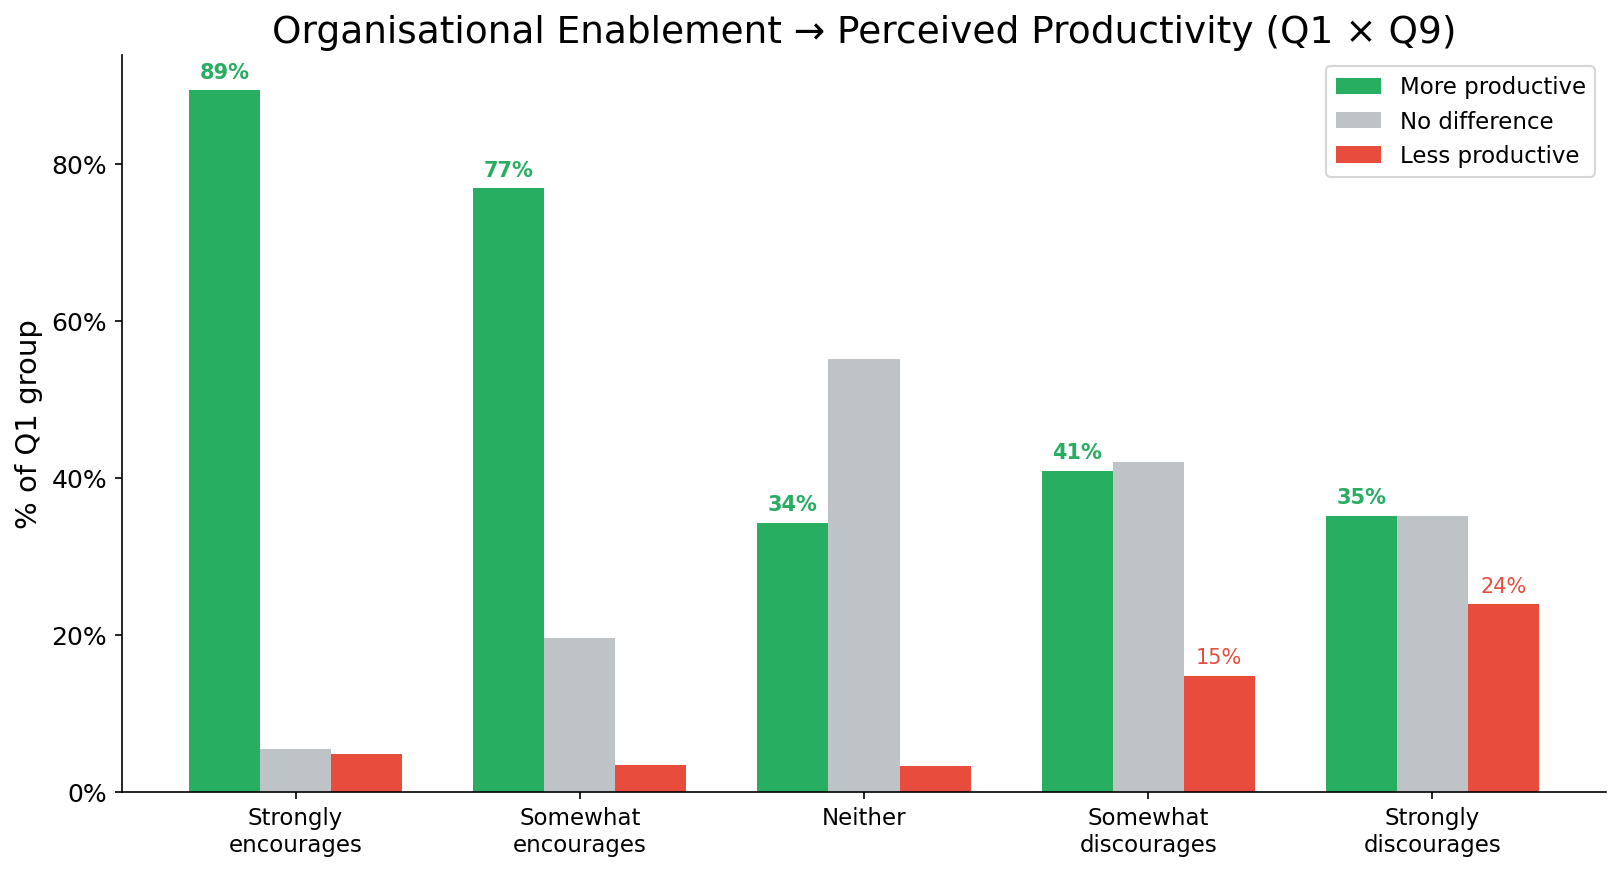

In [6]:
ct = _clean_cols(pd.read_csv(DATA_DIR / "q1_q9_crosstab.csv"))
ct = ct.set_index('q1.a')

# Order from strongly encourages → strongly discourages (exclude Don't know)
q1_order = [
    'Strongly encourages AI adoption',
    'Somewhat encourages AI adoption',
    'Neither encourages nor discourages AI adoption',
    'Somewhat discourages AI adoption',
    'Strongly discourages AI adoption',
]
ct = ct.reindex(q1_order)

prod_col = 'AI tools have helped me become more productive at work'
less_col = 'AI tools have made me become less productive at work'
no_diff_col = 'AI tools have made no difference in my productivity at work'

short_q1 = [
    'Strongly\nencourages', 'Somewhat\nencourages', 'Neither',
    'Somewhat\ndiscourages', 'Strongly\ndiscourages',
]

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(q1_order))
w = 0.25

bars1 = ax.bar(x - w, ct[prod_col], w, label='More productive', color='#27AE60')
bars2 = ax.bar(x, ct[no_diff_col], w, label='No difference', color='#BDC3C7')
bars3 = ax.bar(x + w, ct[less_col], w, label='Less productive', color='#E74C3C')

ax.set_xticks(x)
ax.set_xticklabels(short_q1, fontsize=11)
ax.set_ylabel('% of Q1 group')
ax.set_title('Organisational Enablement \u2192 Perceived Productivity (Q1 \u00d7 Q9)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))
ax.legend(loc='upper right', frameon=True)

# Annotate "more productive" bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#27AE60')

# Annotate "less productive" bars
for bar in bars3:
    h = bar.get_height()
    if h > 5:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h:.0f}%',
                ha='center', va='bottom', fontsize=10, color='#E74C3C')

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q1_q9_enablement_productivity.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Q12 — Rejection Reasons (Horizontal Bar)

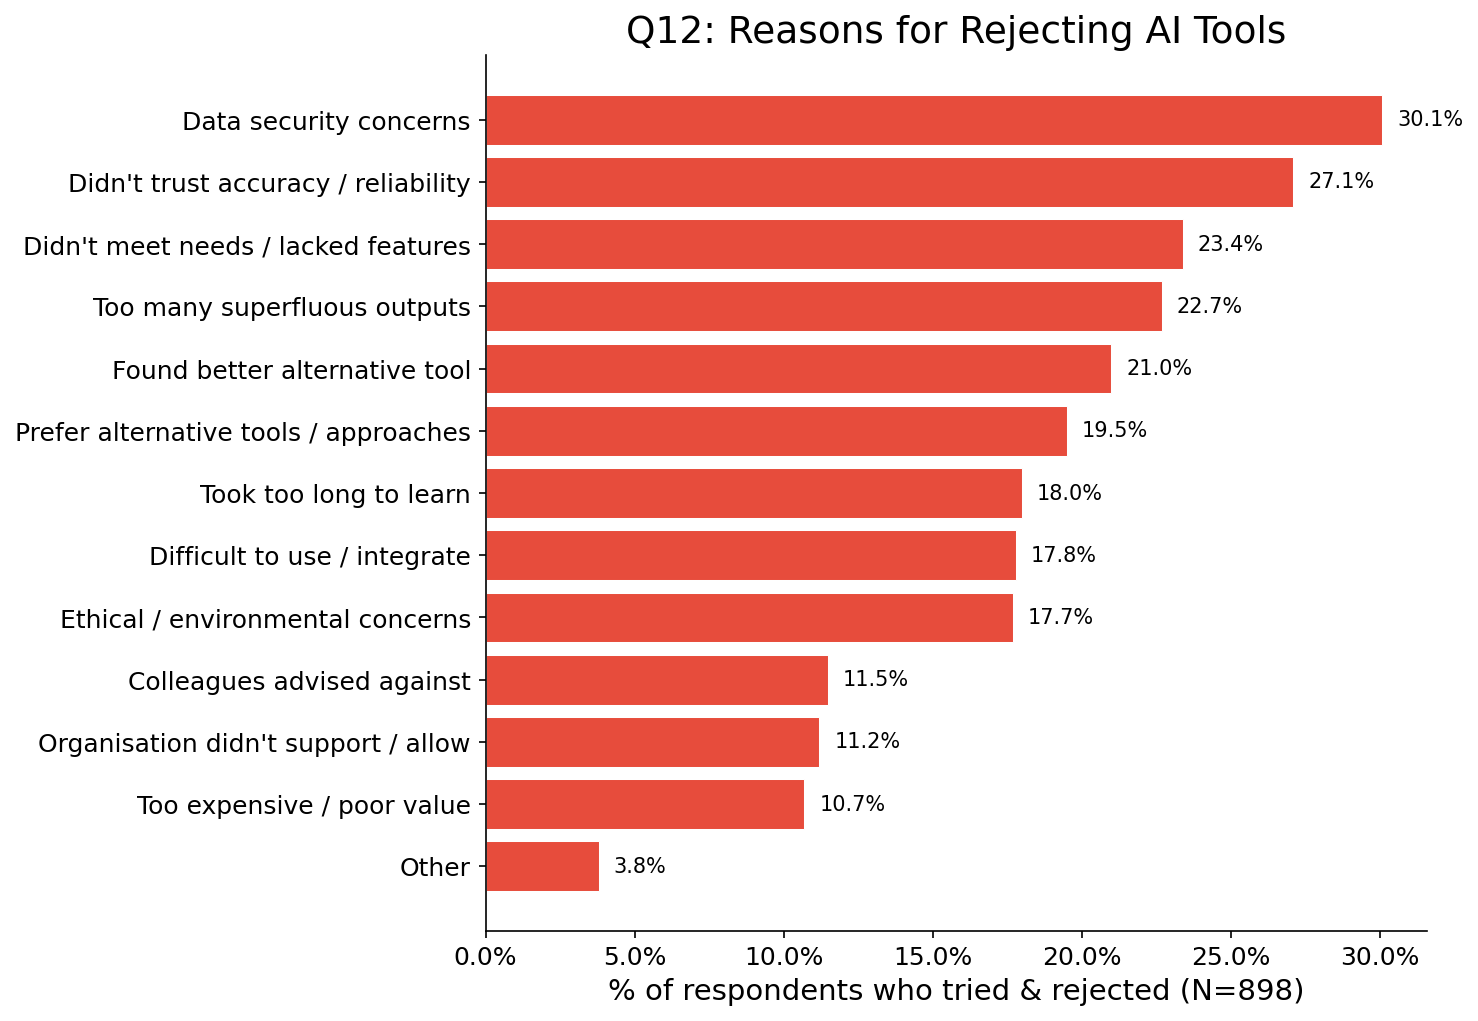

In [7]:
q12 = pd.read_csv(DATA_DIR / "q12_reasons_overall.csv")
q12 = q12.sort_values('Percent_of_Tried_Rejected', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    q12['Reason'], q12['Percent_of_Tried_Rejected'],
    color='#E74C3C', edgecolor='white', linewidth=0.5,
)
ax.set_xlabel('% of respondents who tried & rejected (N=898)')
ax.set_title('Q12: Reasons for Rejecting AI Tools')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(100))

for bar, val in zip(bars, q12['Percent_of_Tried_Rejected']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%',
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_q12_rejection_reasons.png", dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

**Figures saved to `outputs/survey_only/`:**

| # | File | Description |
|---|------|-------------|
| 1 | `fig_q1_enablement_by_sector_stacked.png` | Q1 organisational enablement — stacked bar by sector |
| 2 | `fig_q4_sentiment_by_sector_stacked.png` | Q4 sentiment — stacked bar by sector |
| 3 | `fig_q6_task_usage_overall.png` | Q6 task categories — overall horizontal bar |
| 4 | `fig_q6_task_usage_heatmap.png` | Q6 task usage — sector × category heatmap |
| 5 | `fig_q1_q9_enablement_productivity.png` | Q1 × Q9 enablement–productivity gradient |
| 6 | `fig_q12_rejection_reasons.png` | Q12 rejection reasons — horizontal bar |